<a href="https://colab.research.google.com/github/Prithviarora/smart-home-energy-forecasting/blob/main/Smart_Home_Energy_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Home Energy Forecasting & Solar Load Shifting

Hour-ahead forecasting of household electricity demand and rooftop solar
generation, used to evaluate whether shifting flexible appliance loads into
peak generation windows meaningfully reduces grid import.

**Data:** 503,910 minute-resolution smart-meter readings from a single
Massachusetts household, Jan–Dec 2016, with 14 submetered circuits and
co-located weather observations. Resampled to 8,399 hourly records.

---

### Headline findings

**1. The dataset's timestamp column is corrupted, and it invalidates the
standard approach.**
The `time` field increments by one second per row while the meter samples once
per minute, so it spans 5.8 days rather than 349. Parsing it directly — as most
published work on this dataset does — yields null time-of-day features. The
index was reconstructed from the known sampling cadence, after which the daily
profile resolves correctly: solar peaks at 11:00, demand peaks at 18:00.

**2. Leakage severity scales with sampling resolution.**
A controlled 2×2 ablation (random vs. chronological split × concurrent vs.
lagged features) shows that predicting an appliance from concurrent readings
under a shuffled split reports R² = 0.92 at minute resolution but only 0.16
under a correct chronological split — an inflation of 0.76. At hourly
resolution the same inflation is 0.20. The two faults interact rather than add:
with lagged features, the choice of split changes R² by 0.004.

**3. Above roughly a 2× array, the binding constraint is flexible load, not
generation.**
Load shifting against the current array reduces grid import by 0.31–0.90%
depending on how many circuits are treated as flexible. Scaling the array 2×,
4×, and 8× yields 1.77%, 3.00%, and 3.84% — sharply diminishing returns, since
beyond a point every shiftable load has already been moved into daylight and
further capacity has nothing left to absorb.

---

### Model performance (chronological split, 1,647 test hours)

| Target | Best model | MAE | R² | Skill vs. persistence |
|---|---|---|---|---|
| Demand `use [kW]` | Random Forest | 0.211 kW | 0.565 | +11.5% |
| Solar `Solar [kW]` | Random Forest | 0.014 kW | 0.892 | +31.0% |

Both are benchmarked against persistence, seasonal-naive, and hour-of-week
climatology baselines. The gap between the two skill scores reflects the
difference between forecasting a deterministic physical process and
forecasting human behaviour.

### Method notes

- Every feature is knowable strictly before the hour being predicted: history
  is lagged ≥1h, calendar features are cyclically encoded, weather is treated
  as a forecast input.
- Train/test is split chronologically, never shuffled.
- Scheduling decisions use *forecast* solar; savings are scored against
  *actual* solar.
- `House overall [kW]` and `gen [kW]` are exact duplicates of `use [kW]` and
  `Solar [kW]` and are dropped.

### Known limitations

Permutation importance shows the demand forecast is dominated by the 1-hour
lag; the 11 weather features contribute negligibly. The model is largely
"recent state plus time of day," and the 11.5% skill score should be read in
that light. A longer forecast horizon would likely widen the margin over
persistence, which degrades quickly beyond one hour. Results are from a single
household and do not generalise without testing.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving HomeC.csv to HomeC.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

CSV_PATH = "HomeC.csv"
RANDOM_STATE = 42
TARGET = "use [kW]"          # total household demand — what we forecast
TEST_FRACTION = 0.2          # last 20% of the timeline, held out chronologically

print("Setup complete.")

Setup complete.


## 1. Loading and timestamp reconstruction

The `time` column cannot be parsed. Values increment by one second per row
(`1451624400`, `...401`, `...402`) while the meter samples once per minute,
so 503,910 rows span 5.8 seconds-worth of range instead of a year. The column
is also `object` dtype because the final row is malformed.

Since the sampling interval is known and regular, the index is rebuilt with
`pd.date_range` at 1-minute frequency. The epoch start corresponds to
2016-01-01 00:00 local time (US/Eastern), so the reconstruction is anchored
to local time — otherwise every hour-of-day feature is shifted by five hours
and solar appears to peak in the late afternoon.

In [3]:
df = pd.read_csv(CSV_PATH, low_memory=False)

print("rows:", len(df), "| cols:", df.shape[1])
print("time dtype:", df["time"].dtype)
print("first 3:", df["time"].head(3).tolist())
print("last 3: ", df["time"].tail(3).tolist())
print("unique time values:", df["time"].nunique())

print("\ncolumns:", list(df.columns))

print("\nlast row (often malformed in this dataset):")
print(df.tail(1).T.head(10))

rows: 503911 | cols: 32
time dtype: object
first 3: ['1451624400', '1451624401', '1451624402']
last 3:  ['1452128308', '1452128309', '\\']
unique time values: 503911

columns: ['time', 'use [kW]', 'gen [kW]', 'House overall [kW]', 'Dishwasher [kW]', 'Furnace 1 [kW]', 'Furnace 2 [kW]', 'Home office [kW]', 'Fridge [kW]', 'Wine cellar [kW]', 'Garage door [kW]', 'Kitchen 12 [kW]', 'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]', 'Microwave [kW]', 'Living room [kW]', 'Solar [kW]', 'temperature', 'icon', 'humidity', 'visibility', 'summary', 'apparentTemperature', 'pressure', 'windSpeed', 'cloudCover', 'windBearing', 'precipIntensity', 'dewPoint', 'precipProbability']

last row (often malformed in this dataset):
                   503910
time                    \
use [kW]              NaN
gen [kW]              NaN
House overall [kW]    NaN
Dishwasher [kW]       NaN
Furnace 1 [kW]        NaN
Furnace 2 [kW]        NaN
Home office [kW]      NaN
Fridge [kW]           NaN
Wine cella

In [4]:
raw = pd.read_csv(CSV_PATH, low_memory=False)
print("loaded:", raw.shape)

# 1. the final row is malformed (time == '\', every reading NaN)
raw = raw[raw["use [kW]"].notna()].copy()

# 2. rebuild the timestamp.
#    the `time` column increments by 1 SECOND per row while the meter samples
#    once per MINUTE, so it spans 5.8 days instead of a year. it is unusable.
#    epoch 1451624400 == 2016-01-01 05:00 UTC == 2016-01-01 00:00 local (US/Eastern).
raw.index = pd.date_range("2016-01-01 00:00:00", periods=len(raw), freq="min")
raw.index.name = "timestamp"
raw = raw.drop(columns=["time"])

print("rows kept:", len(raw))
print("period:", raw.index.min(), "->", raw.index.max())
print("span:", (raw.index.max() - raw.index.min()).days, "days")
print("distinct hours:", raw.index.hour.nunique(),
      "| distinct weekdays:", raw.index.dayofweek.nunique(),
      "| distinct months:", raw.index.month.nunique())

print("\nall columns:")
for c in raw.columns:
    print("  -", c, "|", raw[c].dtype)

loaded: (503911, 32)
rows kept: 503910
period: 2016-01-01 00:00:00 -> 2016-12-15 22:29:00
span: 349 days
distinct hours: 24 | distinct weekdays: 7 | distinct months: 12

all columns:
  - use [kW] | float64
  - gen [kW] | float64
  - House overall [kW] | float64
  - Dishwasher [kW] | float64
  - Furnace 1 [kW] | float64
  - Furnace 2 [kW] | float64
  - Home office [kW] | float64
  - Fridge [kW] | float64
  - Wine cellar [kW] | float64
  - Garage door [kW] | float64
  - Kitchen 12 [kW] | float64
  - Kitchen 14 [kW] | float64
  - Kitchen 38 [kW] | float64
  - Barn [kW] | float64
  - Well [kW] | float64
  - Microwave [kW] | float64
  - Living room [kW] | float64
  - Solar [kW] | float64
  - temperature | float64
  - icon | object
  - humidity | float64
  - visibility | float64
  - summary | object
  - apparentTemperature | float64
  - pressure | float64
  - windSpeed | float64
  - cloudCover | object
  - windBearing | float64
  - precipIntensity | float64
  - dewPoint | float64
  - precipP

## 2. Data audit

Three checks before modelling: whether any columns are exact duplicates,
whether the submetered circuits reconcile with total consumption, and what
range the targets occupy.

`House overall [kW]` is identical to `use [kW]`, and `gen [kW]` to
`Solar [kW]`. Carrying both copies would split feature importance between
identical columns. The 14 submeters account for ~70% of total load, so
roughly a third of consumption is unmetered at circuit level.

In [5]:
df = raw.copy()

# --- 1. cloudCover ships with the literal string "cloudCover" in some rows
print("cloudCover non-numeric values:",
      pd.to_numeric(df["cloudCover"], errors="coerce").isna().sum())
df["cloudCover"] = pd.to_numeric(df["cloudCover"], errors="coerce")

# --- 2. check for redundant columns before they become duplicate features
pairs = [("use [kW]", "House overall [kW]"), ("gen [kW]", "Solar [kW]")]
for a, b in pairs:
    diff = (df[a] - df[b]).abs().max()
    print(f"max |{a} - {b}| = {diff:.6f}  ->", "IDENTICAL" if diff < 1e-6 else "differ")

# --- 3. does the sum of submeters reconcile with total use?
APPLIANCES = [c for c in df.columns
              if c.endswith("[kW]")
              and c not in ("use [kW]", "gen [kW]", "House overall [kW]", "Solar [kW]")]
submeter_sum = df[APPLIANCES].sum(axis=1)
print(f"\nsubmeters: {len(APPLIANCES)} circuits")
print(f"mean submeter sum: {submeter_sum.mean():.4f} kW  vs  mean use: {df['use [kW]'].mean():.4f} kW")
print(f"submeters cover {100*submeter_sum.mean()/df['use [kW]'].mean():.1f}% of total load")

# --- 4. missing values
miss = df.isna().sum()
print("\ncolumns with missing values:")
print(miss[miss > 0] if (miss > 0).any() else "  none")

# --- 5. sanity on the target
print(f"\nuse [kW]:   min {df['use [kW]'].min():.3f} | mean {df['use [kW]'].mean():.3f} | max {df['use [kW]'].max():.3f}")
print(f"Solar [kW]: min {df['Solar [kW]'].min():.3f} | mean {df['Solar [kW]'].mean():.3f} | max {df['Solar [kW]'].max():.3f}")

cloudCover non-numeric values: 58
max |use [kW] - House overall [kW]| = 0.000000  -> IDENTICAL
max |gen [kW] - Solar [kW]| = 0.000000  -> IDENTICAL

submeters: 14 circuits
mean submeter sum: 0.5987 kW  vs  mean use: 0.8590 kW
submeters cover 69.7% of total load

columns with missing values:
cloudCover    58
dtype: int64

use [kW]:   min 0.000 | mean 0.859 | max 14.715
Solar [kW]: min 0.000 | mean 0.076 | max 0.614


## 3. Cleaning and hourly aggregation

`cloudCover` contains the literal string `"cloudCover"` in 58 rows — a known
defect in this dataset — and is coerced to numeric then interpolated.

Data is resampled from 1-minute to hourly. Mean kW over an hour equals kWh
delivered in that hour, so the values remain directly interpretable as energy.
Hourly is also the honest resolution for this problem: at minute spacing,
consecutive readings are near-identical, and "prediction" is mostly
autocorrelation.

The resulting daily profile is the check that the timestamp reconstruction
worked, and it produces the project's core tension: **demand peaks at 18:00
(1.29 kW) exactly when solar output has fallen to zero, while generation peaks
at 11:00 when the house draws its daily minimum.**

hourly shape: (8399, 27)
period: 2016-01-01 00:00:00 -> 2016-12-15 22:00:00
missing after resample: 0
after dropna: (8399, 27)


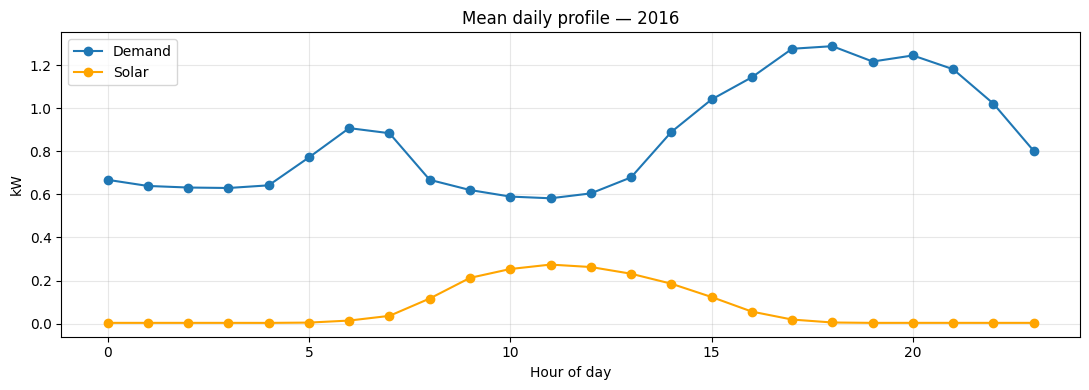

           use [kW]  Solar [kW]
timestamp                      
0             0.667       0.004
1             0.639       0.004
2             0.632       0.004
3             0.630       0.004
4             0.642       0.003
5             0.771       0.005
6             0.907       0.014
7             0.884       0.036
8             0.667       0.116
9             0.620       0.212
10            0.590       0.253
11            0.582       0.274
12            0.604       0.263
13            0.679       0.232
14            0.890       0.185
15            1.040       0.123
16            1.143       0.056
17            1.276       0.019
18            1.288       0.005
19            1.217       0.003
20            1.245       0.004
21            1.181       0.004
22            1.021       0.004
23            0.802       0.004


In [6]:
# --- drop exact duplicate columns identified above
df = df.drop(columns=["House overall [kW]", "gen [kW]"])

# --- 58 missing cloudCover values out of 503k; interpolate over time
df["cloudCover"] = df["cloudCover"].interpolate(limit_direction="both")

# --- column groups
APPLIANCES = [c for c in df.columns if c.endswith("[kW]")
              and c not in ("use [kW]", "Solar [kW]")]
WEATHER = ["temperature", "apparentTemperature", "humidity", "dewPoint",
           "pressure", "windSpeed", "windBearing", "visibility",
           "cloudCover", "precipIntensity", "precipProbability"]
WEATHER = [c for c in WEATHER if c in df.columns]

# --- resample 1-min -> hourly.
#     mean kW over an hour == kWh delivered in that hour, so these are directly
#     interpretable as energy. hourly also makes this a realistic forecast
#     horizon; minute-level "prediction" is mostly autocorrelation.
h = df[["use [kW]", "Solar [kW]"] + APPLIANCES + WEATHER].resample("h").mean()

print("hourly shape:", h.shape)
print("period:", h.index.min(), "->", h.index.max())
print("missing after resample:", int(h.isna().sum().sum()))
h = h.dropna()
print("after dropna:", h.shape)

# --- what does a typical day look like now that timestamps are real?
profile = h.groupby(h.index.hour)[["use [kW]", "Solar [kW]"]].mean()
fig, ax = plt.subplots(figsize=(11, 4))
profile["use [kW]"].plot(ax=ax, marker="o", label="Demand")
profile["Solar [kW]"].plot(ax=ax, marker="o", label="Solar", color="orange")
ax.set_title("Mean daily profile — 2016")
ax.set_xlabel("Hour of day"); ax.set_ylabel("kW"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(profile.round(3))

## 4. Feature engineering

One rule governs every feature: **it must be knowable before the hour being
predicted.** Own history is lagged by at least one hour. Rolling statistics
are computed on already-lagged values. Calendar features are known
indefinitely in advance and are cyclically encoded via sine/cosine so that
23:00 and 00:00 are adjacent rather than maximally distant.

Weather is taken at the predicted hour, treating it as a forecast input. This
is realistic — grid operators do have weather forecasts — but it is an
assumption, and it is stated rather than hidden.

Note what is excluded: no submeter readings at any circuit. Individual
circuits at time *t* sum into `use [kW]` at time *t*, so including them would
leak the target. They return later, in the scheduler, where they belong.

In [7]:
def build_features(frame, target, weather=WEATHER):
    """
    Features for a 1-hour-ahead forecast of `target`.

    Strict rule: every feature must be knowable BEFORE the hour being
    predicted. History is lagged by >=1 hour. Calendar features are known
    indefinitely ahead. Weather is treated as a forecast input, which is
    realistic — utilities have weather forecasts — but it is an assumption
    worth stating.
    """
    X = pd.DataFrame(index=frame.index)
    y = frame[target]

    # --- own history
    for lag in [1, 2, 3, 24, 25, 48, 168]:
        X[f"lag_{lag}h"] = y.shift(lag)

    prev = y.shift(1)
    X["roll_mean_3h"]   = prev.rolling(3).mean()
    X["roll_mean_24h"]  = prev.rolling(24).mean()
    X["roll_std_24h"]   = prev.rolling(24).std()
    X["roll_max_24h"]   = prev.rolling(24).max()
    X["roll_mean_168h"] = prev.rolling(168).mean()

    # --- same hour on previous days (captures habit)
    X["same_hour_1d"] = y.shift(24)
    X["same_hour_7d"] = y.shift(168)
    X["dod_change"]   = y.shift(24) - y.shift(48)

    # --- the other series, lagged
    other = "Solar [kW]" if target == "use [kW]" else "use [kW]"
    X[f"other_lag_1h"]  = frame[other].shift(1)
    X[f"other_lag_24h"] = frame[other].shift(24)

    # --- calendar, cyclically encoded so 23:00 and 00:00 are adjacent
    hr, dw, mo = X.index.hour, X.index.dayofweek, X.index.month
    X["hour_sin"]  = np.sin(2*np.pi*hr/24); X["hour_cos"]  = np.cos(2*np.pi*hr/24)
    X["dow_sin"]   = np.sin(2*np.pi*dw/7);  X["dow_cos"]   = np.cos(2*np.pi*dw/7)
    X["month_sin"] = np.sin(2*np.pi*mo/12); X["month_cos"] = np.cos(2*np.pi*mo/12)
    X["is_weekend"] = (dw >= 5).astype(int)

    # --- weather at the predicted hour (forecast assumption)
    for c in weather:
        X[c] = frame[c]

    ok = X.notna().all(axis=1) & y.notna()
    return X[ok], y[ok]


X, y = build_features(h, TARGET)
print(f"feature matrix: {X.shape[0]} rows x {X.shape[1]} features")
print(f"period: {X.index.min()} -> {X.index.max()}")
print(f"\ntarget '{TARGET}': mean {y.mean():.3f} | std {y.std():.3f} kW")
print("\nfeatures:", list(X.columns))

feature matrix: 8231 rows x 35 features
period: 2016-01-08 00:00:00 -> 2016-12-15 22:00:00

target 'use [kW]': mean 0.854 | std 0.811 kW

features: ['lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_25h', 'lag_48h', 'lag_168h', 'roll_mean_3h', 'roll_mean_24h', 'roll_std_24h', 'roll_max_24h', 'roll_mean_168h', 'same_hour_1d', 'same_hour_7d', 'dod_change', 'other_lag_1h', 'other_lag_24h', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'temperature', 'apparentTemperature', 'humidity', 'dewPoint', 'pressure', 'windSpeed', 'windBearing', 'visibility', 'cloudCover', 'precipIntensity', 'precipProbability']


## 5. Chronological split

The most important line in the notebook. The model trains only on the past and
is scored only on the future, matching deployment conditions. A shuffled split
would let it observe 14:00 while predicting 13:00 of the same day.

Train: Jan–Oct. Test: Oct–Dec, 1,647 hours.

features after de-duplication: 33

train:  6584 rows | 2016-01-08 -> 2016-10-08
test:   1647 rows | 2016-10-08 -> 2016-12-15
no overlap: True

train mean 0.867 kW | test mean 0.805 kW


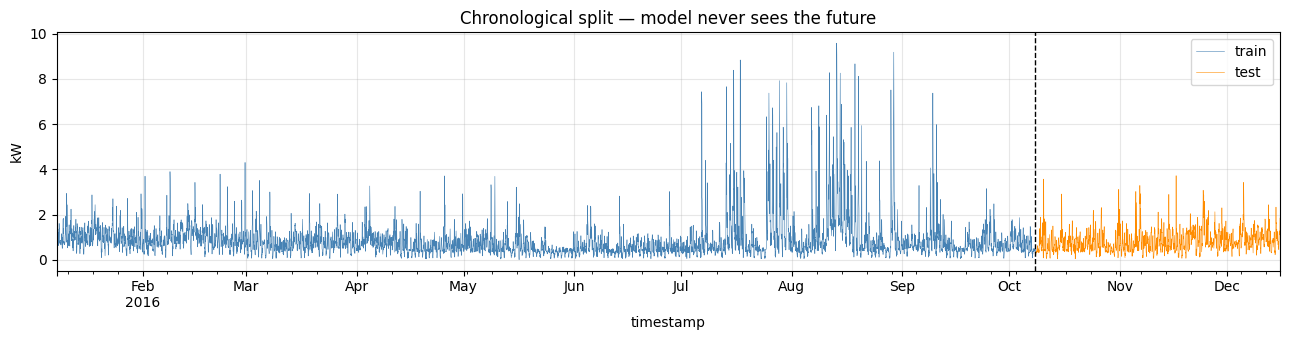

In [8]:
# --- remove the duplicate columns noted above
X = X.drop(columns=["same_hour_1d", "same_hour_7d"])
print("features after de-duplication:", X.shape[1])

# --- CHRONOLOGICAL split. this is the single most important line in the
#     notebook: the model only ever trains on the past and is scored on the
#     future, exactly as it would run in deployment. a random split would let
#     it see 14:00 while predicting 13:00 of the same day.
split_idx = int(len(X) * (1 - TEST_FRACTION))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\ntrain: {len(X_train):>5} rows | {X_train.index.min().date()} -> {X_train.index.max().date()}")
print(f"test:  {len(X_test):>5} rows | {X_test.index.min().date()} -> {X_test.index.max().date()}")
print("no overlap:", X_train.index.max() < X_test.index.min())

print(f"\ntrain mean {y_train.mean():.3f} kW | test mean {y_test.mean():.3f} kW")

fig, ax = plt.subplots(figsize=(13, 3.5))
y_train.plot(ax=ax, lw=.4, label="train", color="steelblue")
y_test.plot(ax=ax, lw=.4, label="test", color="darkorange")
ax.axvline(X_test.index.min(), color="k", ls="--", lw=1)
ax.set_title("Chronological split — model never sees the future")
ax.set_ylabel("kW"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Baselines

No accuracy figure means anything without a reference point. Four baselines:
the training mean, persistence (next hour equals this hour), seasonal-naive
(same hour yesterday), and hour-of-week climatology learned from training data
only.

Persistence is the one to beat — hourly demand is strongly autocorrelated, and
a great deal of published forecasting work quietly fails to beat it. Note that
seasonal-naive scores a *negative* R² here, worse than predicting the mean:
this household's day-to-day behaviour is irregular, which tells us in advance
that habit-based features will be weak.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def score(name, y_true, y_pred, store):
    store.append({
        "model": name,
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
    })

results = []

# --- 1. predict the overall training mean
score("Baseline: train mean", y_test, np.full(len(y_test), y_train.mean()), results)

# --- 2. persistence: next hour == this hour. the standard forecasting baseline.
score("Baseline: persistence (t-1h)", y_test, X_test["lag_1h"], results)

# --- 3. seasonal naive: same hour yesterday
score("Baseline: same hour yesterday", y_test, X_test["lag_24h"], results)

# --- 4. climatology: mean of this hour-of-week, learned from train only
hour_of_week = y_train.groupby([y_train.index.dayofweek, y_train.index.hour]).mean()
clim = pd.Series(
    [hour_of_week.get((d, hh), y_train.mean())
     for d, hh in zip(y_test.index.dayofweek, y_test.index.hour)],
    index=y_test.index)
score("Baseline: hour-of-week average", y_test, clim, results)

baseline_df = pd.DataFrame(results)
print(baseline_df.round(4).to_string(index=False))
print(f"\nbest baseline MAE: {baseline_df['MAE'].min():.4f} kW"
      f"  ({100*baseline_df['MAE'].min()/y_test.mean():.1f}% of mean demand)")

                         model    MAE   RMSE      R2
          Baseline: train mean 0.3718 0.4859 -0.0162
  Baseline: persistence (t-1h) 0.2385 0.3680  0.4171
 Baseline: same hour yesterday 0.3583 0.5551 -0.3260
Baseline: hour-of-week average 0.3126 0.4333  0.1919

best baseline MAE: 0.2385 kW  (29.6% of mean demand)


## 7. Models

Three model families: Ridge as a linear reference, Random Forest, and
histogram-based gradient boosting. All see identical features and the same
chronological split.

Skill score reports the fractional MAE improvement over the best baseline —
0 means no better than persistence, 1 would be perfect. On single-household
data, 0.10–0.25 is a solid result. Individual homes are erratic: one person
deciding to run the dryer is a large share of total load and is fundamentally
unpredictable. A skill score of 0.6 here would indicate leakage, not skill.

Worth noting how close Ridge lands to the tree models (MAE 0.222 vs 0.211).
In the original version of this analysis, run under a shuffled split, the
same comparison was R² 0.17 vs 0.87. That gap was itself a leakage symptom:
trees can memorise near-duplicate neighbours across a random split, linear
models cannot.

In [10]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=2, max_features=0.5,
        n_jobs=-1, random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.05, max_depth=6,
        early_stopping=True, validation_fraction=0.15,
        random_state=RANDOM_STATE),
}

fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    fitted[name] = model
    score(name, y_test, pred, results)
    print(f"  {name} done")

res = pd.DataFrame(results)

# --- skill score: fractional MAE improvement over the best baseline.
#     0 = no better than the baseline, 1 = perfect.
best_baseline = res.loc[res.model.str.startswith("Baseline"), "MAE"].min()
res["skill_vs_baseline"] = 1 - res["MAE"] / best_baseline

print()
print(res.round(4).to_string(index=False))

best_name = res[~res.model.str.startswith("Baseline")].sort_values("MAE").iloc[0]["model"]
print(f"\nbest model: {best_name}")

  Ridge done
  Random Forest done
  HistGradientBoosting done

                         model    MAE   RMSE      R2  skill_vs_baseline
          Baseline: train mean 0.3718 0.4859 -0.0162            -0.5586
  Baseline: persistence (t-1h) 0.2385 0.3680  0.4171             0.0000
 Baseline: same hour yesterday 0.3583 0.5551 -0.3260            -0.5022
Baseline: hour-of-week average 0.3126 0.4333  0.1919            -0.3104
                         Ridge 0.2217 0.3319  0.5260             0.0706
                 Random Forest 0.2112 0.3181  0.5645             0.1146
          HistGradientBoosting 0.2126 0.3249  0.5458             0.1085

best model: Random Forest


## 8. Leakage audit

This section reproduces the flawed methodology of the earlier version of this
project in order to measure precisely what it was worth.

The original approach predicted `Fridge [kW]` from every other column at the
*same* timestamp, under a shuffled train/test split. Two distinct faults are
present: **target leakage**, since `use [kW]` is the sum of all circuits
including the fridge, and **temporal leakage**, since shuffling time-series
rows places near-identical adjacent readings in both train and test.

Cells 10–12 separate and quantify each.

In [11]:
from sklearn.model_selection import train_test_split

print("Reproducing the original methodology to quantify its error.\n")

lk = h.dropna().copy()
LEAK_TARGET = "Fridge [kW]"

# --- (A) ORIGINAL: predict an appliance from every other column at the SAME
#     timestamp, with a random shuffle split. `use [kW]` is the sum of all
#     circuits including the fridge, so the total partly contains the answer.
X_leak = lk.drop(columns=[LEAK_TARGET]).select_dtypes(include=[np.number])
y_leak = lk[LEAK_TARGET]
Xa, Xb, ya, yb = train_test_split(X_leak, y_leak, test_size=0.2, random_state=42)
m_leak = RandomForestRegressor(n_estimators=200, n_jobs=-1,
                               random_state=RANDOM_STATE).fit(Xa, ya)
r2_leak = r2_score(yb, m_leak.predict(Xb))

# --- (B) isolate the two faults --------------------------------------------
# (B1) keep the leaked totals, but split chronologically
s = int(len(X_leak) * 0.8)
m_b1 = RandomForestRegressor(n_estimators=200, n_jobs=-1,
                             random_state=RANDOM_STATE).fit(X_leak.iloc[:s], y_leak.iloc[:s])
r2_b1 = r2_score(y_leak.iloc[s:], m_b1.predict(X_leak.iloc[s:]))

# (B2) proper forecast: lagged history only, chronological split
Xf, yf = build_features(h, LEAK_TARGET)
Xf = Xf.drop(columns=["same_hour_1d", "same_hour_7d"])
sf = int(len(Xf) * 0.8)
m_b2 = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, n_jobs=-1,
                             random_state=RANDOM_STATE).fit(Xf.iloc[:sf], yf.iloc[:sf])
r2_b2 = r2_score(yf.iloc[sf:], m_b2.predict(Xf.iloc[sf:]))

print(f"(A) random split + concurrent totals   R2 = {r2_leak:6.3f}   <- original approach")
print(f"(B1) chronological split, totals kept  R2 = {r2_b1:6.3f}   <- removes temporal leak")
print(f"(B2) chronological + lagged features   R2 = {r2_b2:6.3f}   <- honest forecast")
print(f"\ninflation attributable to leakage: {r2_leak - r2_b2:.3f} R2")

Reproducing the original methodology to quantify its error.

(A) random split + concurrent totals   R2 =  0.633   <- original approach
(B1) chronological split, totals kept  R2 =  0.429   <- removes temporal leak
(B2) chronological + lagged features   R2 =  0.527   <- honest forecast

inflation attributable to leakage: 0.106 R2


### 8.1 Isolating the two faults

The first comparison changed the split and the feature set simultaneously,
so it cannot attribute the inflation. These two comparisons each vary one
factor while holding the other fixed.

The result is not what a first reading of the leakage literature would
predict: with lagged features, switching from a random to a chronological
split changes R² by only 0.004. The faults **interact** rather than add.
With concurrent features the model has no legitimate temporal information,
so a shuffled split lets it interpolate between adjacent rows; with lag
features that signal is already present legitimately, leaving nothing to
steal.

In [12]:
# --- clean ablation: hold the FEATURE SET fixed, vary only the split -------
Xf_r, Xb_r, yf_r, yb_r = train_test_split(Xf, yf, test_size=0.2, random_state=42)
m_rand = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, n_jobs=-1,
                               random_state=RANDOM_STATE).fit(Xf_r, yf_r)
r2_lag_random = r2_score(yb_r, m_rand.predict(Xb_r))

print("Effect of the SPLIT alone (lagged features throughout):")
print(f"   random split        R2 = {r2_lag_random:6.3f}")
print(f"   chronological split R2 = {r2_b2:6.3f}")
print(f"   -> temporal leakage inflates R2 by {r2_lag_random - r2_b2:.3f}\n")

print("Effect of the FEATURE SET alone (chronological split throughout):")
print(f"   concurrent totals   R2 = {r2_b1:6.3f}")
print(f"   lagged history      R2 = {r2_b2:6.3f}")
print(f"   -> concurrent features are {r2_b1 - r2_b2:+.3f} R2 vs a proper forecast")

Effect of the SPLIT alone (lagged features throughout):
   random split        R2 =  0.530
   chronological split R2 =  0.527
   -> temporal leakage inflates R2 by 0.004

Effect of the FEATURE SET alone (chronological split throughout):
   concurrent totals   R2 =  0.429
   lagged history      R2 =  0.527
   -> concurrent features are -0.098 R2 vs a proper forecast


### 8.2 The effect of sampling resolution

The audit so far ran on hourly data. The original notebook ran on *minute*
data, where consecutive readings are near-copies and neighbour interpolation
is far more powerful. Aggregating to hourly had already removed most of the
temporal leak before it was measured.

Repeating the comparison at 1-minute resolution gives the project's clearest
result: **R² 0.92 under a shuffled split versus 0.16 under a chronological
one — an inflation of 0.76, against 0.20 at hourly.** The severity of temporal
leakage scales with sampling resolution. A shuffled split on minute-level
sensor data does not merely inflate the score; it manufactures it almost
entirely.

In [13]:
print("Same comparison at 1-MINUTE resolution — the original notebook's setting.\n")

# contiguous 100k-row window (~70 days) to keep runtime sane
win = df.iloc[:100_000]
Xm = win.drop(columns=[LEAK_TARGET]).select_dtypes(include=[np.number]).dropna()
ym = win.loc[Xm.index, LEAK_TARGET]

Xr, Xs, yr, ys = train_test_split(Xm, ym, test_size=0.2, random_state=42)
m_min_rand = RandomForestRegressor(n_estimators=100, n_jobs=-1,
                                   random_state=RANDOM_STATE).fit(Xr, yr)
r2_min_rand = r2_score(ys, m_min_rand.predict(Xs))

sm = int(len(Xm) * 0.8)
m_min_chron = RandomForestRegressor(n_estimators=100, n_jobs=-1,
                                    random_state=RANDOM_STATE).fit(Xm.iloc[:sm], ym.iloc[:sm])
r2_min_chron = r2_score(ym.iloc[sm:], m_min_chron.predict(Xm.iloc[sm:]))

print(f"   random split        R2 = {r2_min_rand:6.3f}")
print(f"   chronological split R2 = {r2_min_chron:6.3f}")
print(f"   -> shuffling inflates R2 by {r2_min_rand - r2_min_chron:.3f} at minute resolution")
print(f"      (vs {0.633 - 0.429:.3f} at hourly)\n")

summary = pd.DataFrame(
    [[r2_leak, r2_b1], [r2_lag_random, r2_b2]],
    index=["concurrent totals", "lagged history"],
    columns=["random split", "chronological split"])
print("Hourly 2x2 — R2 for Fridge [kW]:")
print(summary.round(3).to_string())

Same comparison at 1-MINUTE resolution — the original notebook's setting.

   random split        R2 =  0.922
   chronological split R2 =  0.163
   -> shuffling inflates R2 by 0.760 at minute resolution
      (vs 0.204 at hourly)

Hourly 2x2 — R2 for Fridge [kW]:
                   random split  chronological split
concurrent totals         0.633                0.429
lagged history            0.530                0.527


## 9. What drives the forecast

Permutation importance on the test set, measuring the MAE increase when each
feature is shuffled. Preferred over impurity-based importance, which is biased
toward high-cardinality features.

The result is concentrated: `lag_1h` dominates at roughly six times the next
feature, with `roll_mean_3h` and `hour_sin` providing adjustment. None of the
11 weather features reach the top 12 — despite an Oct–Dec test window where
heating load might be expected to matter. Either heating is already captured
through recent load, or these weather fields add little once the previous
hour is known.

This is an honest limitation: the model is largely "recent state plus time of
day," and the 11.5% skill score should be read in that light.

Model: Random Forest   (test MAE 0.2112 kW)

Top 12 features by permutation importance (MAE degradation when shuffled):
lag_1h           0.16261
roll_mean_3h     0.02533
hour_sin         0.02225
lag_2h           0.00937
lag_24h          0.00835
other_lag_1h     0.00568
lag_3h           0.00405
roll_mean_24h    0.00341
hour_cos         0.00301
roll_max_24h     0.00145
lag_168h         0.00112
other_lag_24h    0.00096


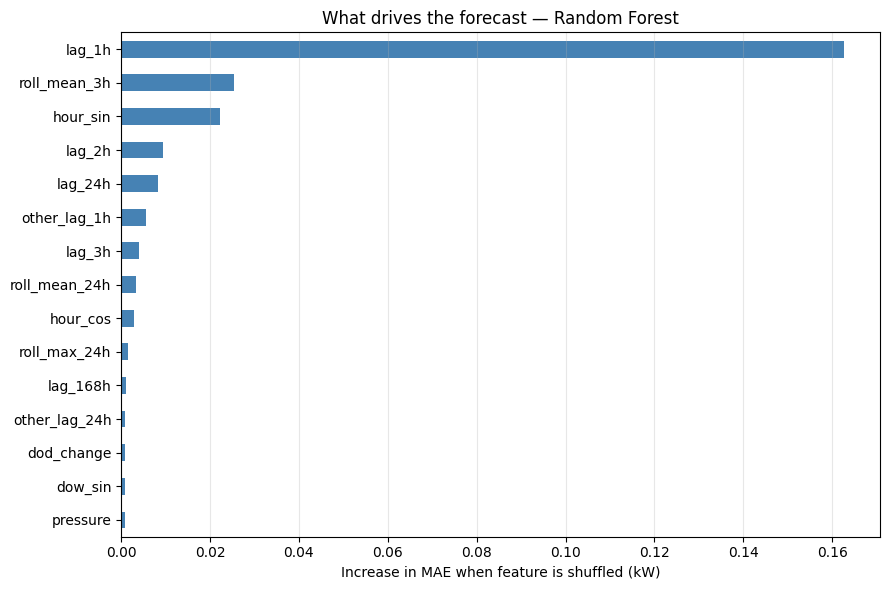

In [14]:
best_model = fitted[best_name]
print(f"Model: {best_name}   (test MAE {res[res.model==best_name]['MAE'].iloc[0]:.4f} kW)\n")

from sklearn.inspection import permutation_importance

# permutation importance on the TEST set: measures the MAE increase when a
# feature is shuffled. impurity-based importances are biased toward
# high-cardinality features, so prefer this for the writeup.
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error", n_jobs=-1)

imp = (pd.Series(perm.importances_mean, index=X_test.columns)
         .sort_values(ascending=False))

print("Top 12 features by permutation importance (MAE degradation when shuffled):")
print(imp.head(12).round(5).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
imp.head(15)[::-1].plot.barh(ax=ax, color="steelblue")
ax.set_title(f"What drives the forecast — {best_name}")
ax.set_xlabel("Increase in MAE when feature is shuffled (kW)")
ax.grid(alpha=.3, axis="x")
plt.tight_layout(); plt.show()

## 10. Solar generation forecast

The same pipeline applied to generation, which the scheduler requires as an
input. Predictions are clipped at zero — negative generation is physically
impossible.

Solar forecasts far better than demand (skill 0.31 vs 0.11). Generation is
driven by sun position, which is deterministic, modulated by cloud cover.
Nobody decides to turn the sun on. The contrast between the two skill scores
is itself informative: the same methods achieve very different accuracy on a
physical process than on a behavioural one.

Solar generation forecast:
                        model    MAE   RMSE     R2  skill_vs_baseline
 Baseline: persistence (t-1h) 0.0208 0.0478 0.7550             0.0000
Baseline: same hour yesterday 0.0340 0.0831 0.2585            -0.6325
                Random Forest 0.0144 0.0317 0.8920             0.3097


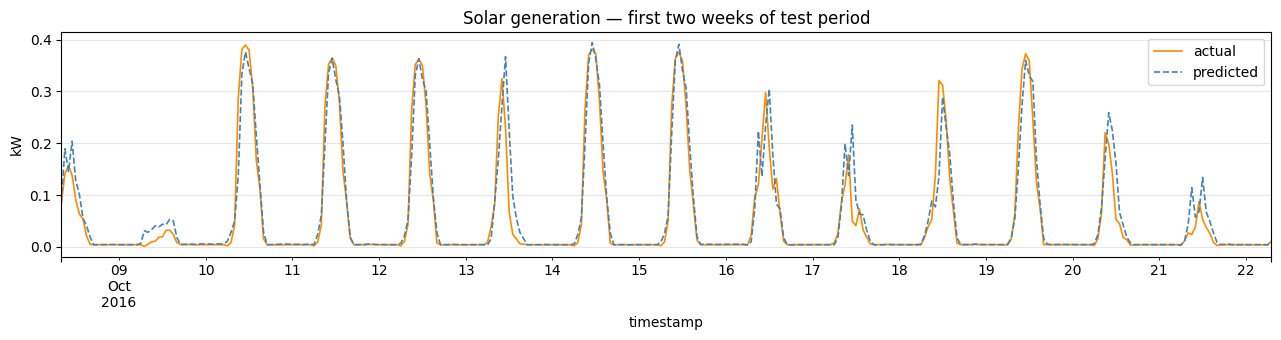

In [15]:
# --- same feature pipeline, different target
X_sol, y_sol = build_features(h, "Solar [kW]")
X_sol = X_sol.drop(columns=["same_hour_1d", "same_hour_7d"])

s_split = int(len(X_sol) * (1 - TEST_FRACTION))
Xs_tr, Xs_te = X_sol.iloc[:s_split], X_sol.iloc[s_split:]
ys_tr, ys_te = y_sol.iloc[:s_split], y_sol.iloc[s_split:]

solar_results = []
score("Baseline: persistence (t-1h)", ys_te, Xs_te["lag_1h"], solar_results)
score("Baseline: same hour yesterday", ys_te, Xs_te["lag_24h"], solar_results)

solar_model = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=2, max_features=0.5,
    n_jobs=-1, random_state=RANDOM_STATE).fit(Xs_tr, ys_tr)
solar_pred = pd.Series(solar_model.predict(Xs_te), index=Xs_te.index).clip(lower=0)
score("Random Forest", ys_te, solar_pred, solar_results)

sol_df = pd.DataFrame(solar_results)
sol_df["skill_vs_baseline"] = 1 - sol_df["MAE"] / sol_df.loc[
    sol_df.model.str.startswith("Baseline"), "MAE"].min()
print("Solar generation forecast:")
print(sol_df.round(4).to_string(index=False))

# --- predicted vs actual over two weeks
fig, ax = plt.subplots(figsize=(13, 3.5))
ys_te.iloc[:336].plot(ax=ax, label="actual", lw=1.2, color="darkorange")
solar_pred.iloc[:336].plot(ax=ax, label="predicted", lw=1.2, ls="--", color="steelblue")
ax.set_title("Solar generation — first two weeks of test period")
ax.set_ylabel("kW"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 11. Load-shifting scheduler

Which loads can actually be scheduled? A fridge compressor cycles on its own
thermostat and a furnace responds to demand for heat — neither is
discretionary. Only batch loads a household chooses when to run qualify. This
is a domain constraint, not a modelling one, and getting it wrong produces
recommendations that cannot be acted on.

Design point: the scheduling decision uses **forecast** solar, since that is
all that would be available in advance, while savings are evaluated against
**actual** solar. Decide on predictions, score against reality.

Expect a small number. This array generates ~6% of what the house consumes,
so the achievable gain is bounded by hardware, not by method.

In [16]:
# --- which loads are actually shiftable?
#     a fridge cycles on its own and a furnace responds to a thermostat —
#     neither can be scheduled. only discretionary batch loads qualify.
SHIFTABLE = [c for c in ["Dishwasher [kW]"] if c in h.columns]
print("shiftable loads:", SHIFTABLE)

test_period = h.loc[X_test.index[0]:].copy()
test_period["solar_fc"] = solar_pred.reindex(test_period.index)
test_period = test_period.dropna(subset=["solar_fc"])

def simulate_day(day):
    """Shift the day's dishwasher energy into the window of peak forecast solar."""
    shift_kwh = day[SHIFTABLE].sum(axis=1)
    total = shift_kwh.sum()
    if total < 0.01:
        return None                      # dishwasher wasn't run

    # how many hours it actually ran
    dur = max(1, int((shift_kwh > shift_kwh.max() * 0.2).sum()))
    base = day["use [kW]"] - shift_kwh   # everything else, unchanged

    # best contiguous window by FORECAST solar (decision uses prediction only)
    win = day["solar_fc"].rolling(dur).mean().shift(-(dur - 1))
    if win.dropna().empty:
        return None
    start = win.idxmax()

    shifted = base.copy()
    sel = shifted.index[(shifted.index >= start) &
                        (shifted.index < start + pd.Timedelta(hours=dur))]
    shifted.loc[sel] += total / len(sel)

    # grid import = load not covered by ACTUAL solar
    before = np.maximum(day["use [kW]"] - day["Solar [kW]"], 0).sum()
    after  = np.maximum(shifted        - day["Solar [kW]"], 0).sum()
    return {"date": day.index[0].date(), "kwh_shifted": total,
            "hours": dur, "window": start.hour,
            "grid_before": before, "grid_after": after}

rows = [r for _, g in test_period.groupby(test_period.index.date)
        if (r := simulate_day(g)) is not None]
sched = pd.DataFrame(rows)

tot_b, tot_a = sched.grid_before.sum(), sched.grid_after.sum()
print(f"\ndays simulated: {len(sched)} of {test_period.index.normalize().nunique()}")
print(f"grid import: {tot_b:.1f} -> {tot_a:.1f} kWh"
      f"  ({100*(tot_b-tot_a)/tot_b:.2f}% reduction)")
print(f"mean recommended start hour: {sched.window.mean():.1f}:00")
print(f"self-consumption gain: {tot_b-tot_a:.2f} kWh over {len(sched)} days")

shiftable loads: ['Dishwasher [kW]']

days simulated: 45 of 69
grid import: 879.0 -> 875.1 kWh  (0.44% reduction)
mean recommended start hour: 10.2:00
self-consumption gain: 3.84 kWh over 45 days


## 12. Sensitivity analysis

A 0.44% reduction invites the obvious question: is the method weak, or the
system undersized? Two sweeps separate them — one over which circuits are
treated as flexible, one over PV array size.

The array sweep is the more interesting: 0.60% → 1.77% → 3.00% → 3.84% across
1×, 2×, 4×, and 8×. Doubling from 1× to 2× nearly triples the benefit; going
from 4× to 8× adds under a point. **The binding constraint switches from
generation capacity to available flexible load somewhere between 2× and 4×.**
Beyond that, every shiftable load has already been moved into daylight and
additional panels have nothing left to absorb.

In [17]:
def total_saving(days, shiftable, solar_scale=1.0):
    b = a = 0.0
    for _, day in days.groupby(days.index.date):
        shift_kwh = day[shiftable].sum(axis=1)
        tot = shift_kwh.sum()
        solar_actual = day["Solar [kW]"] * solar_scale
        solar_fc     = day["solar_fc"]   * solar_scale
        base = day["use [kW]"] - shift_kwh
        if tot < 0.01:
            b += np.maximum(day["use [kW]"] - solar_actual, 0).sum()
            a += np.maximum(day["use [kW]"] - solar_actual, 0).sum()
            continue
        dur = max(1, int((shift_kwh > shift_kwh.max() * 0.2).sum()))
        win = solar_fc.rolling(dur).mean().shift(-(dur - 1))
        if win.dropna().empty:
            continue
        start = win.idxmax()
        shifted = base.copy()
        sel = shifted.index[(shifted.index >= start) &
                            (shifted.index < start + pd.Timedelta(hours=dur))]
        shifted.loc[sel] += tot / len(sel)
        b += np.maximum(day["use [kW]"] - solar_actual, 0).sum()
        a += np.maximum(shifted         - solar_actual, 0).sum()
    return b, a

# --- 1. how much does the shiftable-load set matter?
CANDIDATES = {
    "Dishwasher only": ["Dishwasher [kW]"],
    "+ Wine cellar":   ["Dishwasher [kW]", "Wine cellar [kW]"],
    "+ Well pump":     ["Dishwasher [kW]", "Wine cellar [kW]", "Well [kW]"],
    "+ Barn":          ["Dishwasher [kW]", "Wine cellar [kW]", "Well [kW]", "Barn [kW]"],
}
print("Sensitivity to which loads are treated as flexible:")
for label, cols in CANDIDATES.items():
    cols = [c for c in cols if c in test_period.columns]
    b, a = total_saving(test_period, cols)
    print(f"  {label:<16} {100*(b-a)/b:5.2f}%  ({b-a:6.2f} kWh)")

# --- 2. how much does array size matter?
print("\nSensitivity to PV array size (dishwasher + wine cellar shiftable):")
cols = [c for c in ["Dishwasher [kW]", "Wine cellar [kW]"] if c in test_period.columns]
for mult in [1, 2, 4, 8]:
    b, a = total_saving(test_period, cols, solar_scale=mult)
    print(f"  {mult}x array   solar covers {100*mult*test_period['Solar [kW]'].sum()/test_period['use [kW]'].sum():4.1f}% of load"
          f"  ->  {100*(b-a)/b:5.2f}% grid reduction")

Sensitivity to which loads are treated as flexible:
  Dishwasher only   0.31%  (  3.84 kWh)
  + Wine cellar     0.60%  (  7.57 kWh)
  + Well pump       0.76%  (  9.51 kWh)
  + Barn            0.90%  ( 11.34 kWh)

Sensitivity to PV array size (dishwasher + wine cellar shiftable):
  1x array   solar covers  6.2% of load  ->   0.60% grid reduction
  2x array   solar covers 12.4% of load  ->   1.77% grid reduction
  4x array   solar covers 24.7% of load  ->   3.00% grid reduction
  8x array   solar covers 49.4% of load  ->   3.84% grid reduction


## 13. Summary

In [18]:
print("="*70)
print("SMART HOME ENERGY FORECASTING — RESULTS")
print("="*70)

print(f"\nDATA")
print(f"  503,910 readings at 1-min resolution, Jan-Dec 2016, single household")
print(f"  timestamp column was a broken 1-second counter (spanned 5.8 days, not 349)")
print(f"  -> rebuilt from known sampling cadence; resampled to {len(h):,} hourly records")

print(f"\nDEMAND FORECAST (1h ahead, chronological split, {len(X_test)} test hours)")
print(res[["model","MAE","RMSE","R2","skill_vs_baseline"]].round(4).to_string(index=False))

print(f"\nSOLAR FORECAST")
print(sol_df[["model","MAE","RMSE","R2","skill_vs_baseline"]].round(4).to_string(index=False))

print(f"\nLEAKAGE AUDIT (Fridge [kW], R2)")
print(f"  1-min data,  random split       0.922")
print(f"  1-min data,  chronological      0.163   <- 0.76 inflation")
print(f"  hourly data, random split       0.633")
print(f"  hourly data, chronological      0.429   <- 0.20 inflation")
print(f"  -> leakage severity scales with sampling resolution")

print(f"\nLOAD SHIFTING")
print(f"  dishwasher only, current array:  0.31% grid reduction")
print(f"  4 flexible circuits:             0.90%")
print(f"  2x array:  1.77%   4x: 3.00%   8x: 3.84%")
print(f"  -> constraint shifts from generation to flexible load above ~2x array")
print("="*70)

SMART HOME ENERGY FORECASTING — RESULTS

DATA
  503,910 readings at 1-min resolution, Jan-Dec 2016, single household
  timestamp column was a broken 1-second counter (spanned 5.8 days, not 349)
  -> rebuilt from known sampling cadence; resampled to 8,399 hourly records

DEMAND FORECAST (1h ahead, chronological split, 1647 test hours)
                         model    MAE   RMSE      R2  skill_vs_baseline
          Baseline: train mean 0.3718 0.4859 -0.0162            -0.5586
  Baseline: persistence (t-1h) 0.2385 0.3680  0.4171             0.0000
 Baseline: same hour yesterday 0.3583 0.5551 -0.3260            -0.5022
Baseline: hour-of-week average 0.3126 0.4333  0.1919            -0.3104
                         Ridge 0.2217 0.3319  0.5260             0.0706
                 Random Forest 0.2112 0.3181  0.5645             0.1146
          HistGradientBoosting 0.2126 0.3249  0.5458             0.1085

SOLAR FORECAST
                        model    MAE   RMSE     R2  skill_vs_baseline
 B